Bibliotekos

In [49]:
import pandas as pd
import random
from sklearn.model_selection import train_test_split
import numpy as np
import statsmodels.formula.api as smf

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import matplotlib.ticker as ticker

Duomenų paruošimas

In [10]:
data = pd.read_csv("../datasets/miami-housing.csv")
data.describe()

,LATITUDE,LONGITUDE,PARCELNO,SALE_PRC,LND_SQFOOT,TOT_LVG_AREA,SPEC_FEAT_VAL,RAIL_DIST,OCEAN_DIST,WATER_DIST,CNTR_DIST,SUBCNTR_DI,HWY_DIST,age,avno60plus,month_sold,structure_quality
count,13932.000000,13932.000000,1.393200e+04,1.393200e+04,13932.000000,13932.000000,13932.000000,13932.000000,13932.000000,13932.000000,13932.000000,13932.000000,13932.000000,13932.000000,13932.000000,13932.000000,13932.000000
mean,25.728811,-80.327475,2.356496e+12,3.999419e+05,8620.879917,2058.044574,9562.493468,8348.548715,31690.993798,11960.285235,68490.327132,41115.047265,7723.770693,30.669251,0.014930,6.655828,3.513997
std,0.140633,0.089199,1.199290e+12,3.172147e+05,6070.088742,813.538535,13890.967782,6178.027333,17595.079468,11932.992369,32008.474808,22161.825935,6068.936108,21.153068,0.121276,3.301523,1.097444
min,25.434333,-80.542172,1.020008e+11,7.200000e+04,1248.000000,854.000000,0.000000,10.500000,236.100000,0.000000,3825.600000,1462.800000,90.200000,0.000000,0.000000,1.000000,1.000000
25%,25.620056,-80.403278,1.079160e+12,2.350000e+05,5400.000000,1470.000000,810.000000,3299.450000,18079.350000,2675.850000,42823.100000,23996.250000,2998.125000,14.000000,0.000000,4.000000,2.000000
50%,25.731810,-80.338911,3.040300e+12,3.100000e+05,7500.000000,1877.500000,2765.500000,7106.300000,28541.750000,6922.600000,65852.400000,41109.900000,6159.750000,26.000000,0.000000,7.000000,4.000000
75%,25.852269,-80.258019,3.060170e+12,4.280000e+05,9126.250000,2471.000000,12352.250000,12102.600000,44310.650000,19200.000000,89358.325000,53949.375000,10854.200000,46.000000,0.000000,9.000000,4.000000
max,25.974382,-80.119746,3.660170e+12,2.650000e+06,57064.000000,6287.000000,175020.000000,29621.500000,75744.900000,50399.800000,159976.500000,110553.800000,48167.300000,96.000000,1.000000,12.000000,5.000000


In [11]:
data = data.astype({
    'structure_quality': 'category',
    'month_sold': 'category',
    'avno60plus': 'category'
})

In [12]:
data.isna().sum()

LATITUDE             0
LONGITUDE            0
PARCELNO             0
SALE_PRC             0
LND_SQFOOT           0
TOT_LVG_AREA         0
SPEC_FEAT_VAL        0
RAIL_DIST            0
OCEAN_DIST           0
WATER_DIST           0
CNTR_DIST            0
SUBCNTR_DI           0
HWY_DIST             0
age                  0
avno60plus           0
month_sold           0
structure_quality    0
dtype: int64

In [13]:
train_data, test_data = train_test_split(
    data, 
    test_size=0.2, 
    stratify=data['structure_quality'], 
    random_state=1
)

train_data = train_data.sample(frac=1, random_state=1).reset_index(drop=True)
test_data = test_data.sample(frac=1, random_state=1).reset_index(drop=True)

# Pradinė analizė

In [14]:
data.head()

,LATITUDE,LONGITUDE,PARCELNO,SALE_PRC,LND_SQFOOT,TOT_LVG_AREA,SPEC_FEAT_VAL,RAIL_DIST,OCEAN_DIST,WATER_DIST,CNTR_DIST,SUBCNTR_DI,HWY_DIST,age,avno60plus,month_sold,structure_quality
0,25.891031,-80.160561,622280070620,440000.0,9375,1753,0,2815.9,12811.4,347.6,42815.3,37742.2,15954.9,67,0,8,4
1,25.891324,-80.153968,622280100460,349000.0,9375,1715,0,4359.1,10648.4,337.8,43504.9,37340.5,18125.0,63,0,9,4
2,25.891334,-80.153740,622280100470,800000.0,9375,2276,49206,4412.9,10574.1,297.1,43530.4,37328.7,18200.5,61,0,2,4
3,25.891765,-80.152657,622280100530,988000.0,12450,2058,10033,4585.0,10156.5,0.0,43797.5,37423.2,18514.4,63,0,9,4
4,25.891825,-80.154639,622280100200,755000.0,12800,1684,16681,4063.4,10836.8,326.6,43599.7,37550.8,17903.4,42,0,7,4


## Išskirtys

In [19]:
def count_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    H = Q3 - Q1
    
    low = Q1 - 3 * H
    high = Q3 + 3 * H
    
    outliers = ((series < low) | (series > high)).sum()
 
    return pd.Series({
        'Q1': Q1, 'Q3': Q3, 'H': H,
        'outliers': outliers
    })

exclude_cols = ['LATITUDE', 'LONGITUDE', 'PARCELNO']
numeric_cols = data.select_dtypes(include=['number']).drop(columns=exclude_cols, errors='ignore')

outlier_summary = numeric_cols.apply(count_outliers).T.reset_index().rename(columns={'index': 'variable'})

print(outlier_summary)

         variable          Q1          Q3           H  outliers
0        SALE_PRC  235000.000  428000.000  193000.000     712.0
1      LND_SQFOOT    5400.000    9126.250    3726.250     460.0
2    TOT_LVG_AREA    1470.000    2471.000    1001.000      48.0
3   SPEC_FEAT_VAL     810.000   12352.250   11542.250     272.0
4       RAIL_DIST    3299.450   12102.600    8803.150       0.0
5      OCEAN_DIST   18079.350   44310.650   26231.300       0.0
6      WATER_DIST    2675.850   19200.000   16524.150       0.0
7       CNTR_DIST   42823.100   89358.325   46535.225       0.0
8      SUBCNTR_DI   23996.250   53949.375   29953.125       0.0
9        HWY_DIST    2998.125   10854.200    7856.075      20.0
10            age      14.000      46.000      32.000       0.0


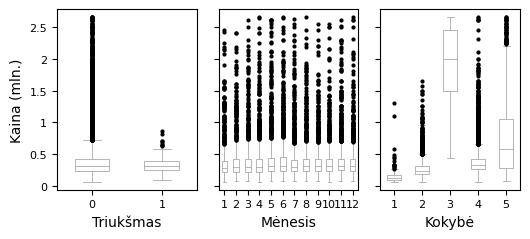

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(5.4, 2.5), sharey=True)

sns.boxplot(data=data, x='avno60plus', y='SALE_PRC', ax=axes[0], width=0.5, color='white', linewidth=0.5, fliersize=2,  # Adjusts the size of the points
    flierprops={'markerfacecolor': 'black', 'markeredgecolor': 'black'})
axes[0].set(xlabel='Triukšmas', ylabel='Kaina (mln.)')

axes[0].yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x*1e-6:g}'))

sns.boxplot(data=data, x='month_sold', y='SALE_PRC', ax=axes[1], width=0.5, color='white', linewidth=0.5, fliersize=2,  # Adjusts the size of the points
    flierprops={'markerfacecolor': 'black', 'markeredgecolor': 'black'})
axes[1].set(xlabel='Mėnesis', ylabel=None)

sns.boxplot(data=data, x='structure_quality', y='SALE_PRC', ax=axes[2], width=0.5, color='white', linewidth=0.5, fliersize=2,  # Adjusts the size of the points
    flierprops={'markerfacecolor': 'black', 'markeredgecolor': 'black'})
axes[2].set(xlabel='Kokybė', ylabel=None)

for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=8)

plt.tight_layout()

plt.show()

## Charakteristikos

In [39]:
numeric_data = data.select_dtypes(include=['number'])

char = numeric_data.agg(['min', 'max', 'mean', 'std', 'median'])

char.loc['q25'] = numeric_data.quantile(0.25)
char.loc['q75'] = numeric_data.quantile(0.75)

char = char.T

char = char.reset_index().rename(columns={'index': 'Variable'})

print(char.round(4))

         Variable           min           max          mean           std  \
0        LATITUDE  2.543430e+01  2.597440e+01  2.572880e+01  1.406000e-01   
1       LONGITUDE -8.054220e+01 -8.011970e+01 -8.032750e+01  8.920000e-02   
2        PARCELNO  1.020008e+11  3.660170e+12  2.356496e+12  1.199290e+12   
3        SALE_PRC  7.200000e+04  2.650000e+06  3.999419e+05  3.172147e+05   
4      LND_SQFOOT  1.248000e+03  5.706400e+04  8.620880e+03  6.070089e+03   
5    TOT_LVG_AREA  8.540000e+02  6.287000e+03  2.058045e+03  8.135385e+02   
6   SPEC_FEAT_VAL  0.000000e+00  1.750200e+05  9.562494e+03  1.389097e+04   
7       RAIL_DIST  1.050000e+01  2.962150e+04  8.348549e+03  6.178027e+03   
8      OCEAN_DIST  2.361000e+02  7.574490e+04  3.169099e+04  1.759508e+04   
9      WATER_DIST  0.000000e+00  5.039980e+04  1.196029e+04  1.193299e+04   
10      CNTR_DIST  3.825600e+03  1.599765e+05  6.849033e+04  3.200847e+04   
11     SUBCNTR_DI  1.462800e+03  1.105538e+05  4.111505e+04  2.216183e+04   

## Kokybinių kintamųjų analizė

In [40]:
print(data['avno60plus'].value_counts())

print(data['structure_quality'].value_counts())

print(pd.crosstab(data['structure_quality'], data['avno60plus']))

avno60plus
0    13724
1      208
Name: count, dtype: int64
structure_quality
4    7625
2    4110
5    2002
1     179
3      16
Name: count, dtype: int64
avno60plus            0    1
structure_quality           
1                   179    0
2                  4106    4
3                    16    0
4                  7506  119
5                  1917   85


## Sąryšiai

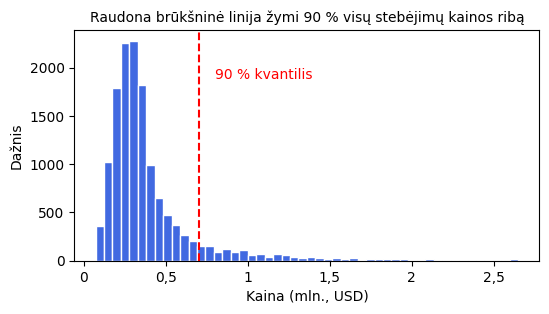

In [ ]:
q90 = data['SALE_PRC'].quantile(0.9)

fig, ax = plt.subplots(figsize=(6, 3))

ax.hist(data['SALE_PRC'], bins=50, color='royalblue', edgecolor='white')

ax.axvline(x=q90, color='red', linestyle='--', linewidth=1.5)

ax.text(x=q90 + 100000, y=2000, s="90 % kvantilis", 
        color='red', fontsize=10, verticalalignment='top')

def format_func(x, pos):
    val = x * 1e-6
    return f'{val:g}'.replace('.', ',')

ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_func))

ax.xaxis.set_major_locator(ticker.MultipleLocator(500000))

ax.set_title("Raudona brūkšninė linija žymi 90 % visų stebėjimų kainos ribą", fontsize=10)
ax.set_xlabel("Kaina (mln., USD)")
ax.set_ylabel("Dažnis")

ax.set_facecolor('white')
ax.grid(False)
for spine in ax.spines.values():
    spine.set_edgecolor('black')

plt.show()

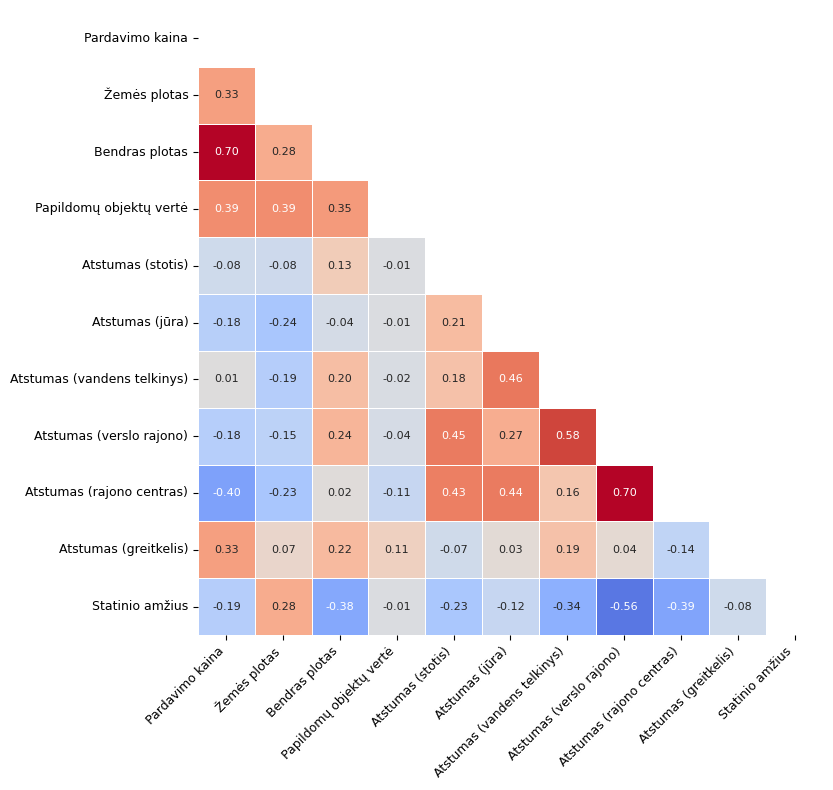

In [ ]:
rename_map = {
    'SALE_PRC': 'Pardavimo kaina',
    'LND_SQFOOT': 'Žemės plotas',
    'TOT_LVG_AREA': 'Bendras plotas',
    'SPEC_FEAT_VAL': 'Papildomų objektų vertė',
    'RAIL_DIST': 'Atstumas (stotis)',
    'OCEAN_DIST': 'Atstumas (jūra)',
    'WATER_DIST': 'Atstumas (vandens telkinys)',
    'CNTR_DIST': 'Atstumas (verslo rajono)',
    'SUBCNTR_DI': 'Atstumas (rajono centras)',
    'HWY_DIST': 'Atstumas (greitkelis)',
    'age': 'Statinio amžius'
}

df_subset = data.select_dtypes(include=['number']).drop(
    columns=['LATITUDE', 'LONGITUDE', 'PARCELNO'], errors='ignore'
).rename(columns=rename_map)

cor_matrix = df_subset.corr(method='spearman')

plt.figure(figsize=(10, 8))

mask = np.triu(np.ones_like(cor_matrix, dtype=bool))

ax = sns.heatmap(
    cor_matrix, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    center=0, 
    square=True, 
    linewidths=.5, 
    cbar=False,
    annot_kws={"size": 8}
)

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

C:\Users\crist\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
C:\Users\crist\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
C:\Users\crist\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
C:\Users\crist\AppData\Lo

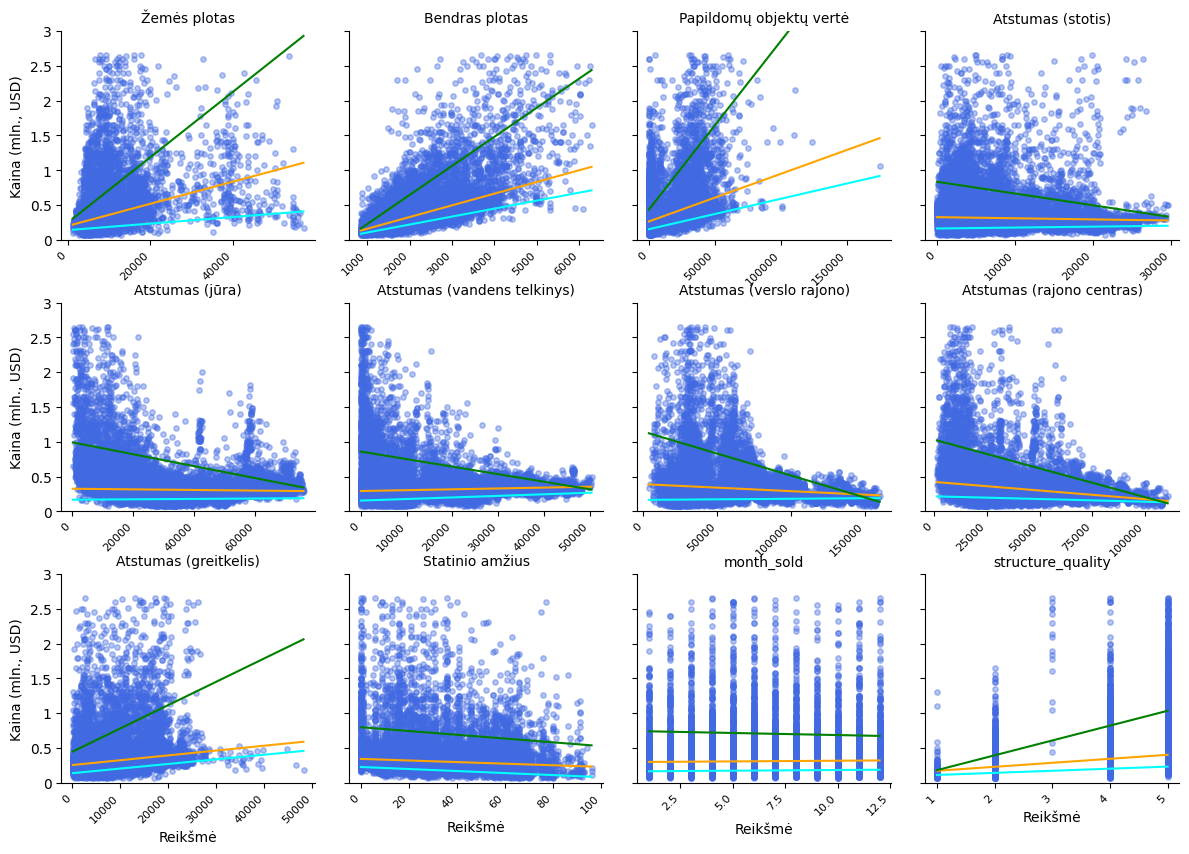

In [54]:
data_renamed = data.rename(columns=rename_map).drop(
    columns=['LATITUDE', 'LONGITUDE', 'PARCELNO', 'avno60plus'], 
    errors='ignore'
)

df_long = data_renamed.melt(
    id_vars=['Pardavimo kaina'], 
    var_name='kintamasis', 
    value_name='reiksme'
)

def plot_quantiles(x, y, **kwargs):
    ax = plt.gca()
    # Scatter plot
    ax.scatter(x, y, alpha=0.4, s=15, color="royalblue", label="_nolegend_")
    
    temp_df = pd.DataFrame({'x': x, 'y': y})
    temp_df = temp_df.dropna()
    
    quantiles = {0.1: 'cyan', 0.5: 'orange', 0.9: 'green'}
    
    x_range = np.linspace(temp_df['x'].min(), temp_df['x'].max(), 50)
    
    for q, color in quantiles.items():
        model = smf.quantreg('y ~ x', temp_df).fit(q=q)
        y_pred = model.params['Intercept'] + model.params['x'] * x_range
        ax.plot(x_range, y_pred, color=color, linewidth=1.5)

g = sns.FacetGrid(df_long, col="kintamasis", col_wrap=4, sharex=False, sharey=True, height=3)

g.map(plot_quantiles, "reiksme", "Pardavimo kaina")

g.set_titles("{col_name}")
g.set_axis_labels("Reikšmė", "Kaina (mln., USD)")

def millions(x, pos): return f'{x*1e-6:g}'
g.axes[0].yaxis.set_major_formatter(FuncFormatter(millions))

g.set(ylim=(0, 3000000))

for ax in g.axes.flat:
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)

plt.subplots_adjust(top=0.9, hspace=0.3)
plt.show()